# Scikit-Learn for Dummies like Me

Finally, We are going to understand **Scikit-Learn**. It's very very important to know **Sklearn** (abbreviation of **Scikit-Learn**) as a **Machine Learning** student . 

So, Lets start the journey.

---
## 01 · Introduction

**Scikit-learn**, also known as **sklearn**, is an open-source, robust **Python** machine learning library. It was created to help simplify the process of implementing machine learning and statistical models in **Python**.

**Sklearn** was built on top of **NumPy** and **ScyPy**, which are **Python** libraries for numerical computing, and **Matplotlib**, which is a **Python** library for data visualization. It works on all types of numeric data stored as either **NumPy arrays**, **SciPy sparse matrices**, and all other data types that can be converted to numeric arrays such as **Pandas DataFrames**. It offers a clean and consistent interface that helps both beginners and experienced users work efficiently.


**Key Features of Sklearn** :

- Supports tasks like classification, regression, clustering and preprocessing.
- Makes model building fast and reliable.
- Provides ready-to-use tools for training and evaluation.
- Reduces complexity by avoiding manual implementation of algorithms.


---
## 02 · Loading Dataset

In **Machine Leaning** workflow, first thing is loading a dataset. **Sklearn** provides some builtin datasets like **Iris Dataset**, **Digits** and **Boston Housing** and we will use **Iris Dataset**.

Before going on, let's know some info about a **Dataset**, A dataset consists of :

- Features (`X`): Input variables that describe the data.
- Target (`y`): The value we want to predict.

Lets load the **Iris** dataset:

In [1]:
# loading Iris dataset from sklearn :
from sklearn.datasets import load_iris

print('Dataset loaded successfully.')

Dataset loaded successfully.


In [2]:
# Dataset accessing :
iris = load_iris() 

type(iris)

sklearn.utils._bunch.Bunch

---
The above code returns a `dictionary-like` object (`numpy.ndarray`) containing the data along with metadata about the data it contains. 
Thats why `iris.head()` will show error.  We can see the data with metadata by running `iris` in notebook. 
The dataset we need is in the `.data` attribute returned by `load_iris()`.

We can access it as an attribute of the `iris` instance as follows: 

In [3]:
# accessing iris dataset :
iris.data.shape

(150, 4)

In [4]:
# firs 5 rows of iris data : 
iris.data[:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

---
It is just a large **NumPy Array** with 150 rows and 4 columns . But we can get `feature` names and `target` names of this dataset by `features_names` and `target_names` attribute. 

Lets see these attributes :

In [5]:
# features and target :
print('Feture names : ', iris.feature_names)
print('Target names : ', iris.target_names)

Feture names :  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names :  ['setosa' 'versicolor' 'virginica']


---
So, the `data` attribute contains all features data and `target` attribute contains all labels.

Lets make a **DataFrame** by pandas from these divided informations :

In [6]:
# importing pandas :
import pandas as pd 

dataset = iris.data
features = iris.feature_names

# making dataframe :
iris_df = pd.DataFrame(dataset, columns=features)

# adding target to complete the dataset :
iris_df['label'] = iris.target

# lets see our dataframe :
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Finally, we have made a complete DataFrame from **NumPy Array** and **Python List**.

---
## 03 · Data Exploration

Now we will do a brief exploration to get a better idea of what this dataset contains; this will give me a better idea of how to process the data. 

Lets explore the Dataframe :

In [7]:
# shape of the df :
iris_df.shape

(150, 5)

In [8]:
# information : 
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   label              150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [9]:
# describe the df : 
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [10]:
# head 
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [11]:
# tail 
iris_df.tail() 

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [12]:
# value counts of label :
iris_df.label.value_counts()

label
0    50
1    50
2    50
Name: count, dtype: int64

---
## 04 · Data Preprocessing

We have a decent understanding of what our data looks like now. When we’ve reached this point, it usually means we’re ready to begin moving toward preparing the data to be fed into a machine learning model. 

**Data processing** is a vital step in the machine learning workflow because data from the real world is messy.

It may contain: 

- Missing values
- Redundant values
- Outliers
- Errors
- Noise

We must deal with all of this before feeding the data to a machine learning model; otherwise, the model will incorporate these mistakes into its approximation function – it will learn to make mistakes on new instances. This is what formed the famous machine learning saying, **“Garbage in, garbage out.”** 

Another reason is that machine learning models typically require numeric data.  

Other than our data being on different scales, there’s not much else wrong with our data at first glance. To combat this problem, let’s standardize the features using **sklearn’s StandardScaler class**; this will standardize features to have a **mean** of 0 and a **standard deviation** of 1. 

Here’s the code: 

In [13]:
# importing standardScalar 
from sklearn.preprocessing import StandardScaler

# splitting data into features and target :
X = iris_df[features].copy() 
y = iris_df['label'].copy() 

# Instantiating scaler and fitting on features :
scaler = StandardScaler() 
#scaler.fit(X) 

# transforming features : 
#X_scalled = scaler.transform(X)

# shortcut fitting and transforming : 
X_scaled = scaler.fit_transform(X)

# first 5 instance of our dataset :
X_scaled[:5]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ]])

---
## 05 · Splitting the Dataset

Before a machine learning model can make predictions, it must be trained on a set of data to learn an approximation function. But how will we know if the model performs well on data it has not seen before? We won’t unless we test it out. 

One way to test a machine learning model before placing it in an environment where it impacts others is to **split** the training data into a training and test set and use the test set to evaluate what the model has learned; this is known as **Offline Evaluation**. 

There are several ways to split data into train and test sets, but **Scikit-learn** has a built-in function to do this on our behalf called `train_test_split()`. 
We’ll use this function to split our data such that 70% is used to train the model and 30% is used to evaluate the model's ability to generalize to unseen instances.

To evaluate a model fairly, We split data into:

- Training set: Used to train the model
- Testing set: Used to evaluate how well the model generalizes

We’ll use this function to split our data such that 70% is used to train the model and 30% is used to evaluate the model's ability to generalize to unseen instances. 

Lets split the Dataset :

In [14]:
# importing train_test_split :
from sklearn.model_selection import train_test_split

# splitting our dataset : 
#X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.3, random_state=25)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y , test_size=0.3, random_state=25)

print(f'Train set size : {round(len(X_train) / len(X) * 100)}%')
print(f'Test  set size : {round(len(X_test) / len(X) * 100)}%')

Train set size : 70%
Test  set size : 30%


Using `train_test_split`, we splitted the Iris dataset so that 70% is for training and 30% for testing (`test_size=0.3`). `random_state=25` ensures reproducibility.

After splitting, we get:

- X_train, y_train -> Training data
- X_test, y_test -> Testing data


---
## 06 · Model Building

Now that our data is ready, it’s time to train a machine learning model. **Scikit-learn** has many algorithms with a consistent interface for training, prediction and evaluation. Thanks to **sklearn**, building a machine learning model is extremely simple.

---
### A · **Decision Tree**

**Decision Tree** is a machine learning algorithm that learns to make decisions from data. It is like a chart, where each branch of the tree depends on a question or condition, and each leaf (called a node) represents a decision or outcome.

**Decision Tree** basically use “yes / no” questions or some mathematical condition to predict something by arranging them like the leaves of a tree.

Let’s understand some of the things behind a **Decision Tree** :

**Entropy** is the main criterion of **Decision Tree**, which is a measure of the randomness or chaos of the data. Simply put, **Entropy** helps to understand how precise or uncertain a dataset is. If all parts of the data are the same, such as a box containing only apples, then the entropy will be 0, because there is no uncertainty here. On the other hand, if the box contains 50% apples and 50% oranges, then the entropy will be high, because there is confusion about which fruit is which. **Decision Tree** use entropy to create queries that break down data into parts, reduce clutter, and find a specific pattern. Thus, entropy serves as the basis for creating **Decision Tree** conditions and making decisions.

If the **Decision Tree** is too deep, it creates unnecessary branches, which is called **overfitting** . **Pruning** is used for this. It cuts out unnecessary branches, so that the model is simpler and works better with new data.

Now we are going to build a **Decision Tree Classifier** model to predict **Iris flowers** :

In [15]:
# importing Decision Tree :
from sklearn.tree import DecisionTreeClassifier, plot_tree

# instnatiating the model 
tree = DecisionTreeClassifier(random_state=19, max_depth=5)

# training the model
tree.fit(X_train, y_train)

# making predictions with model
tree_pred = tree.predict(X_test)

# getting accuricy of model :
# each model has a built-in score() method to get accuricy score.
accuricy = tree.score(X_test, y_test)

# model accuricy :
print(f'Decision Tree Model Accuricy : {round(accuricy * 100, 2)}%')

Decision Tree Model Accuricy : 95.56%


In [16]:
# lets see our predictions :
print(tree_pred)
print('Output type :' , type(tree_pred))

[0 1 2 1 2 1 2 0 1 1 0 0 0 1 0 1 2 2 1 1 1 1 1 0 0 2 1 2 2 0 1 2 2 0 2 1 1
 0 0 0 0 0 0 0 2]
Output type : <class 'numpy.ndarray'>


---
Now We are going to draw a simple **Decision Tree** plot by `plot_tree`.

Lets do it . . .

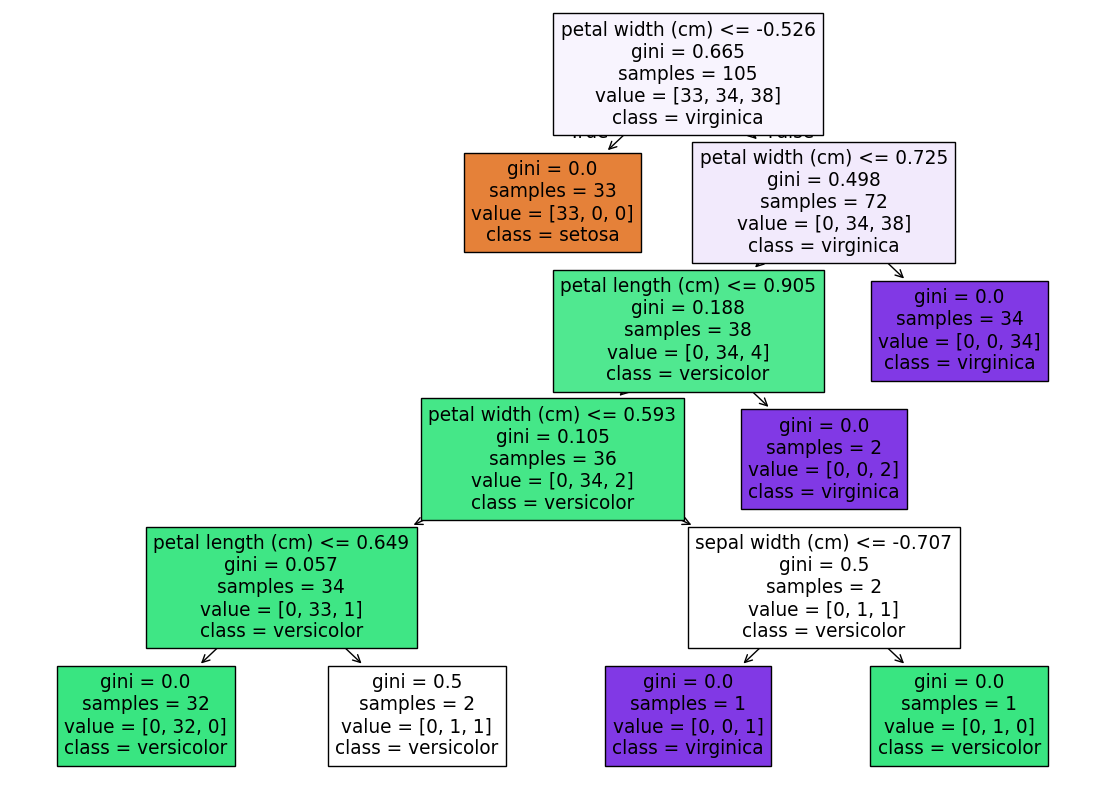

In [17]:
# drawing plot by `plot_tree` :
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))
plot_tree(tree, feature_names=features, class_names=iris.target_names, filled=True)
plt.show()

---
### B · **Random Forest**

When it comes to machine learning models, **Random Forest** comes in, a powerful and efficient algorithm that uses multiple **Decision Trees** to make more accurate and stable predictions.

**Random Forest** is an **ensemble model** (Model made up of multiple models). It creates multiple decision trees and combines their results to reach a final conclusion.

Let's explain the working steps of **Random Forest** in simple terms :

1. **Bootstrap sample generation** :

**Random Forest** generates multiple samples from the training data. Each sample is randomly generated from the original data and may contain duplicate data. This process is called bootstrapping.

2. **Decision Tree generation** :

A **Decision Tree** is generated from each bootstrap sample. However, at each node (each leaf called a node) split, it uses a randomly selected subset instead of the entire feature set. This randomness ensures that the trees are distinct.

3. **Prediction** :

When new data arrives, each tree in the **Random Forest** makes a prediction. **In the case of classification**, each tree casts its vote, and the label with the most votes is the final prediction. **In the case of regression**, the average of the predictions of all the trees is determined as the final result.

Lets build a **Random Forest Classifier** model to predict **Iris flowers** :

In [18]:
# importing random forest classifier :
from sklearn.ensemble import RandomForestClassifier

# instnatiating the model :
rfc = RandomForestClassifier(n_estimators=100, random_state=19)

# training the model :
rfc.fit(X_train, y_train)

# making predictions with model :
rfc_pred = rfc.predict(X_test)

# getting accuricy of model :
# each model has a built-in score() method to get accuricy score.
rfc_accuricy = rfc.score(X_test, y_test)

# model accuricy :
print(f'Random Forest Model Accuricy : {round(rfc_accuricy * 100, 2)}%')

Random Forest Model Accuricy : 95.56%
